# Tutorial 6: Galactic Binaries & RJMCMC

In the sixth tutorial, we will examine Galactic Binary waveforms. We will then use them in fixed-dimensional MCMC and then in RJMCMC. We use RJMCMC to perform model selection on the number of sources in the data. 

In [1]:
# # if running in google colab
# !apt-get install liblapacke-dev libgsl-dev
# !pip install eryn lisaanalysistools chainconsumer corner
# !pip install gbgpu

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
from lisatools.utils.constants import *
from lisatools.sensitivity import get_sensitivity

## Task 1: Build and plot a Galacic Binary waveform using `GBGPU`

We will start by generating Galactic Binary waveforms with `GBGPU`. Pick reasonable parameters, build a waveform and plot it against the LISA A channel TDI Sensitivity Curve (`A1TDISens`) in the characteristic strain representation. You can access the information after waveform generation as attributes on the class. This may be updated in the future.

Useful documentation:
* [GBGPU](https://mikekatz04.github.io/GBGPU/html/user/main.html#gbgpu.gbgpu.GBGPU)

银河系双星（Galactic Binary）的引力波信号

In [3]:
# imports
from gbgpu.gbgpu import GBGPU

In [4]:
gb = GBGPU()

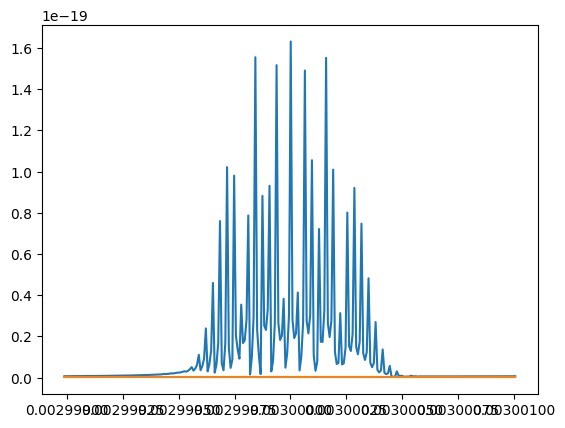

In [5]:
amp = 2e-23  
f0 = 3e-3  
fdot = 7.538331e-18  
fddot = 0.0 
phi0 = 0.1 
iota = 0.2  
psi = 0.3 
lam = 4.15  
beta = -0.12  
Tobs = 4 * YRSID_SI
gb.run_wave(amp, f0, fdot, fddot, phi0, iota, psi, lam, beta, N=256) #N=256是一个经验值
#如果 $N$ 取得太小（比如 16），你会发现画出来的波形在边缘被强行切断了
# 如果取得太大（比如 2048），你的代码运行速度会明显变慢。
plt.plot(gb.freqs[0], gb.freqs[0] * np.abs(gb.A[0]))
#gb.A[0],返回A道的信息
plt.plot(gb.freqs[0], get_sensitivity(gb.freqs[0], sens_fn="A1TDISens", return_type="char_strain"))

## Task 2: Run an MCMC over a single GB source

Run a fixed-dimensional MCMC run with a chosen GB source. Fix the sky location for now to simplify the problem computationally (this is especially important for the next section on RJ with GBs). So, you will sample over 6 of the 8 parameters. Discuss or think about reasonable priors for these parameters and how you would determine that. For simplicity, we recommend using tightly (but not too tightly) bound uniform distributions for this example setup.

There is a faster `get_ll` method on the `GBGPU` class. However, it may be easier to use the full `AnalysisContainer` setup. This will make the RJ part more straight forward, but is not actually ideal for fixed-dimensional MCMC on GBs. 

After the run is complete, plot the posterior distribution with `chainconsumer` or `corner`. 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  
from lisatools.sensitivity import get_sensitivity
from lisatools.analysiscontainer import AnalysisContainer
from lisatools.datacontainer import DataResidualArray
from lisatools.sensitivity import AE1SensitivityMatrix
import shutil
import os
from gpry.run import Runner
from gbgpu.gbgpu import GBGPU
gb = GBGPU() 

/home/yudh/miniconda3/envs/lisa_final/lib/python3.11/site-packages/gpry/mpi.py:19: UserWarning: mpi4py could not be imported. It is optional but recommended for faster running in parallel.
  warn(


In [7]:
amp = 2e-23  
f0 = 3e-3  
fdot = 7.538331e-18  
fddot = 0.0 
phi0 = 0.1 
iota = 0.2  
psi = 0.3 
lam = 4.15  
beta = -0.12  
Tobs = YRSID_SI

bounds = [
    [1e-23, 1e-21],              
    [0.00299995, 0.00300005],    
    [1e-18, 1e-17],              
    [0.0, 2 * np.pi],            
    [0.0, np.pi],                
    [0.0, np.pi]                 
]


In [8]:
lam_default = 4.13
beta_default = -0.15
default_values = np.array([lam_default, beta_default])
N_wave = 256

injection_params = np.array([amp, f0, fdot, 0.0, phi0, iota, psi, lam_default, beta_default])

Tobs_run = YRSID_SI
dt = 5.0
N = int(Tobs_run / dt)
Tobs_run = N * dt
df = 1 / Tobs_run
f_arr = np.arange(0.0, 1/(2 * dt) + df, df)


data_orig = np.asarray(gb.inject_signal(*injection_params, T=Tobs_run, dt=dt, N=N_wave))
data = DataResidualArray(data_orig.copy(), f_arr=f_arr)
sens_mat = AE1SensitivityMatrix(f_arr)
analysis = AnalysisContainer(data, sens_mat)

/home/yudh/miniconda3/envs/lisa_final/lib/python3.11/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/yudh/miniconda3/envs/lisa_final/lib/python3.11/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/yudh/miniconda3/envs/lisa_final/lib/python3.11/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/yudh/miniconda3/envs/lisa_final/lib/python3.11/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/yudh/miniconda3/envs/lisa_final/lib/python3.11/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi * frq / C_S

In [9]:
N_wave = 256
def like_wrap(x, analysis1, data, fd, Tobs, dt, default_values):
    input_parameters = np.zeros(9)
    #其中第3个位置fddot保持为0即可。
    input_parameters[np.array([0, 1, 2, 4, 5, 6])] = x
    input_parameters[np.array([7, 8])] = default_values
    gb.run_wave(*input_parameters, T=Tobs, dt=dt, N=N_wave) 
    
    A = gb.A[0]
    E = gb.E[0]
    # 真实的信号和生成的256个点的信号对齐
    start_ind = int(gb.freqs[0][0] / df)
    template = DataResidualArray(np.array([A, E]), f_arr=gb.freqs[0])
    data_tmp = DataResidualArray(data[:, start_ind:start_ind + N_wave], f_arr=fd[start_ind:start_ind + N_wave])
    sens_mat = AE1SensitivityMatrix(data_tmp.f_arr)
    analysis = AnalysisContainer(data_tmp, sens_mat)
    ll = analysis.template_likelihood(template)
    return ll

In [10]:
def gpry_log_like(A, f0, fdot, phi0, iota, psi):
    x_arr = np.array([A, f0, fdot, phi0, iota, psi], dtype=float)
    try:
        ll = like_wrap(
            x_arr, analysis, data_orig, analysis.data_res_arr.f_arr, 
            Tobs, dt, default_values
        )
        return float(np.squeeze(ll))
    except Exception:
        return -np.inf  

In [11]:
test_ll = gpry_log_like(amp, f0, fdot, phi0, iota, psi)
print(f"注入点的对数似然值: {test_ll}") 

注入点的对数似然值: 1.1368683772161603e-13


Successfully created the directory gpry_final
Initializing GP with the following options:
* Kernel:
    3.16**2 * RBF(length_scale=[0.1, 0.1, 0.1, 0.1, 0.1, 0.1])
  with hyperparameters:
    - Hyperparameter(name='k1__constant_value', value_type='numeric', bounds=array([[1.e-04, 1.e+06]]), max_length=None, n_elements=1, fixed=False, dynamic=False)
    - Hyperparameter(name='k2__length_scale', value_type='numeric', bounds=array([[1.e-03, 1.e+01],
       [1.e-03, 1.e+01],
       [1.e-03, 1.e+01],
       [1.e-03, 1.e+01],
       [1.e-03, 1.e+01],
       [1.e-03, 1.e+01]]), max_length=None, n_elements=6, fixed=False, dynamic=False)
* Noise level: 0.01
* Optimizer: fmin_l_bfgs_b
* Optimizer restarts: 22
* X-preprocessor: True
* y-preprocessor: True
* SVM to account for infinities: True
Initialized GPry.
| Drawing initial samples.                                                    |


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [01:51<00:00,  1.12s/it]


[EVALUATION] (1.1e+02 sec) Evaluated the true log-posterior at 93400 location(s), of which 100 returned a finite value.
[FIT] (2.8 sec) Fitted GP model with new acquired points, including GPR hyperparameters. 100 finite points were added to the GPR.
| Iteration 1 (at most 76100 left)                                            |
| Total truth evals: 93400 (100 finite) of 550000 (or 1500 finite)            |
[ACQUISITION] (3.1 sec) Proposed 6 point(s) for truth evaluation.
[EVALUATION] (0.0083 sec) Evaluated the true log-posterior at 6 location(s), of which 6 returned a finite value.
[FIT] (1.3 sec) Fitted log(p) surrogate model with 6 new points, of which 6 were added to the GPR. GPR hyperparameters were fit with 1 restart(s) per MPI process.
Current maximum log-posterior: 63.92918240427518
Current GPR kernel: 0.999**2 * RBF(length_scale=[0.0327, 10, 0.015, 0.374, 0.19, 0.186])
[CONVERGENCE] (0.00032 sec) Evaluated convergence criterion: 
[CONVERGENCE] - CorrectCounter [n]: 8.2e+02 (lim

/home/yudh/miniconda3/envs/lisa_final/lib/python3.11/site-packages/gpry/mc.py:413: UserWarning: Importing the default NS PolyChord failed (Err msg: External nested sampler Polychord cannot be imported. Check out installation instructions at https://github.com/PolyChord/PolyChordLite (or select an alternative nested sampler, e.g. UltraNest).). Defaulting to UltraNest.
  warnings.warn(


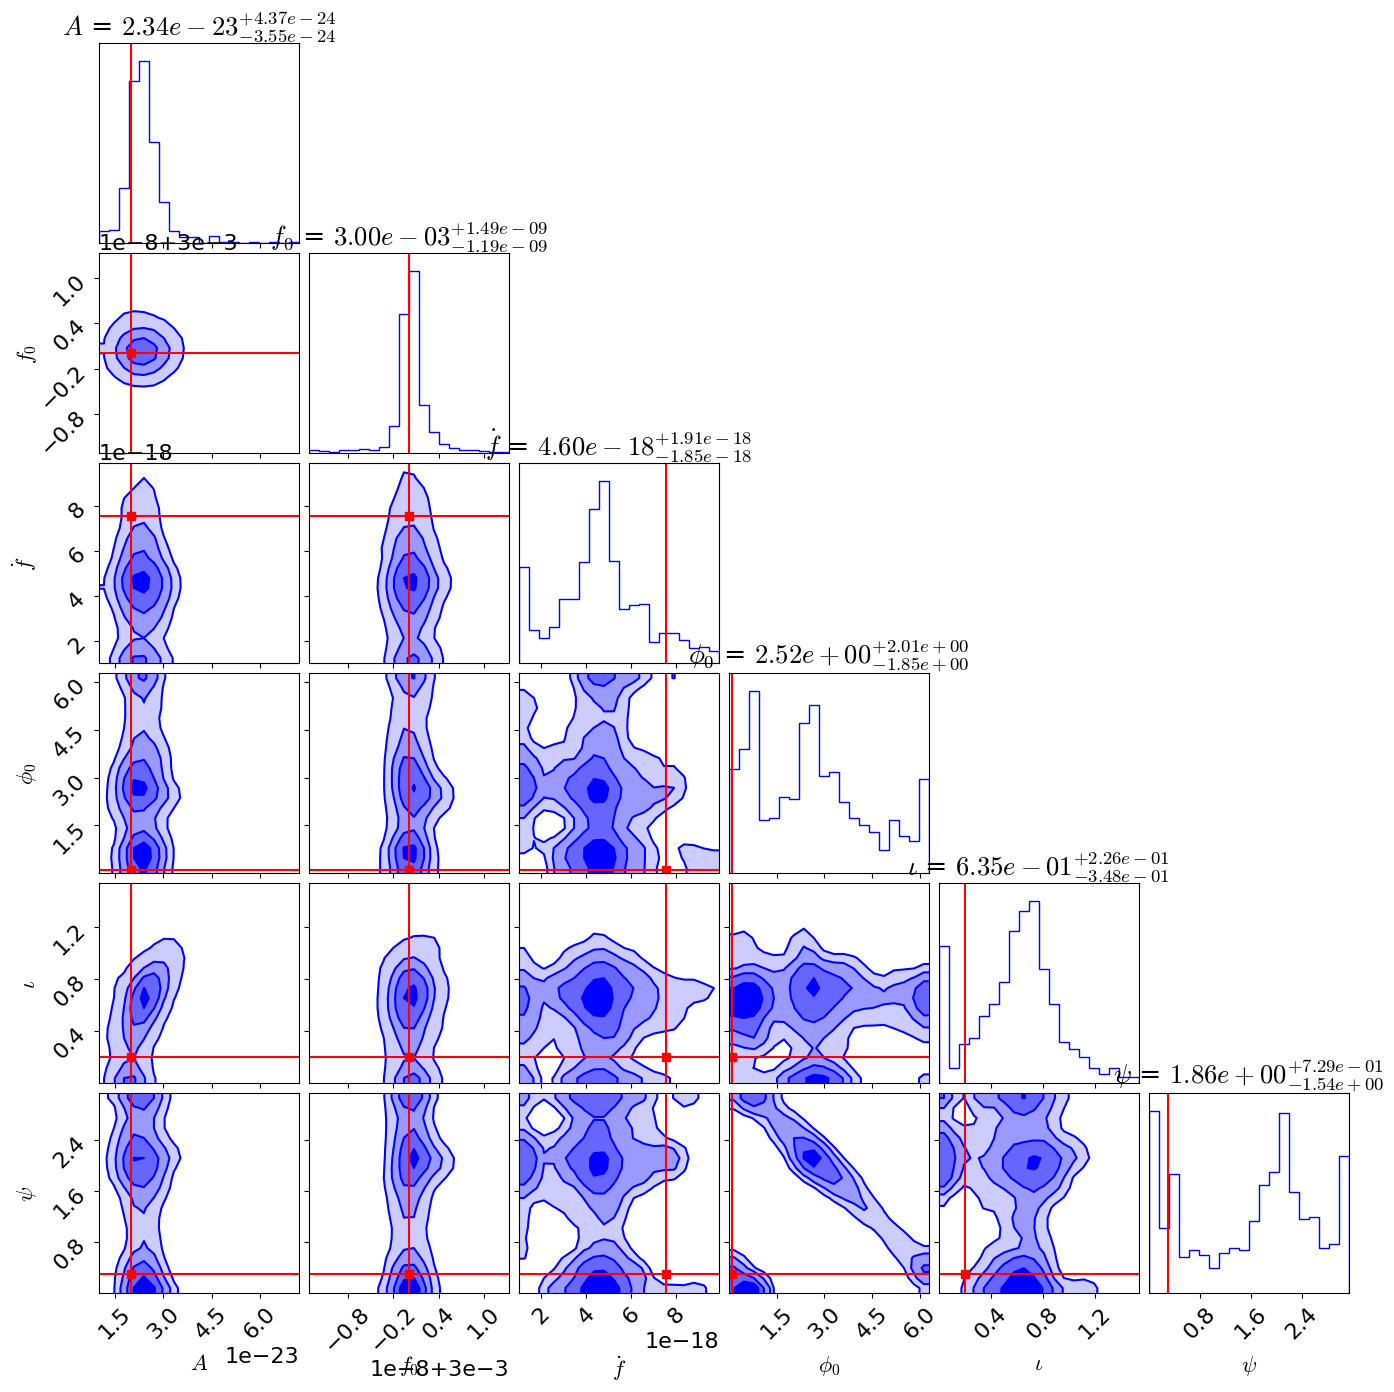

In [12]:
import shutil
import os
import numpy as np
import matplotlib.pyplot as plt
from gpry.run import Runner
import corner

checkpoint = "gpry_final" 
if os.path.exists(checkpoint):
    shutil.rmtree(checkpoint)

my_options = {
    "n_initial": 100,        
    "max_initial": 500000,    
    "max_finite": 1500,      
    "max_total": 550000,     
    "n_points_per_acq": 6    
}

# 2. 初始化 Runner
runner = Runner(
    gpry_log_like, 
    bounds=bounds, 
    checkpoint=checkpoint, 
    load_checkpoint="overwrite",    
    options=my_options,
    convergence_criterion={"CorrectCounter": {"limit": 25}}
)


try:
    runner.run()
except Exception as e:
    print("\n")
    pass

plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.fontset"] = "cm"

# 提取数据
X_samples = runner.gpr.X_train_
y_samples = runner.gpr.y_train_

# 自适应提取精华点
n_extract = min(len(y_samples), 800)
best_indices = np.argsort(y_samples)[-n_extract:] 
final_samples_norm = X_samples[best_indices]

# 反归一化
bounds_arr = np.array(bounds)
final_samples_phys = final_samples_norm * (bounds_arr[:, 1] - bounds_arr[:, 0]) + bounds_arr[:, 0]

# 设置红线
truths = [amp, f0, fdot, phi0, iota, psi]

# 最终出图
fig = corner.corner(
    final_samples_phys, 
    labels=[r"$A$", r"$f_0$", r"$\dot{f}$", r"$\phi_0$", r"$\iota$", r"$\psi$"],
    truths=truths,
    truth_color="red",
    show_titles=True,
    title_fmt='.2e', 
    color="blue",
    smooth=1.0,
    plot_datapoints=(n_extract < 500), 
    fill_contours=True
)

plt.show()

## Task 3: RJ with GBs

Our final task will be to run RJMCMC on a few close Galactic Binaries. The key component here is the "global" Likelihood function. Work to build a function that takes from Eryn and adjustable length array of templates to be summed into a global template prior to the Likelihood computations. This will be a bit tedious, but is very important for understanding this process. 

There is another nuance in this problem that must be dealt with to get this all to work. In the fixed-dimensional case with one binary, the default stretch proposal is effectively invariant to the scale along each dimension as there is no mixing of dimensional information when making a  proposal, $\vec{Y} = \vec{X}_j + z\left(\vec{X}_i - \vec{X}_j\right)$. The default `GaussianMove` that we used in tutorial 5 requires an inversion of the covariance matrix. If we sample in the parameters we used above ($A$, $f_0$, $\dot{f}$, etc.), the scale differences between parameters will cause numerical issues with matrix inversion and multiplication. 

There is a small variety of ways to deal with this. Here are two possibilities:

1) You can log scale and reduce each parmeter so they are all of order 1. This would involve changing the priors and making sure you include this conversion in your Likelihood function. You can use `eryn.utils.TransformContainer` to do this conversion if you would like.
2) You can create your own proposal where you assume a diagonal covariance and generate the information yourself. I have chosen to take this route for this example. **Hint**: the Eryn tutorial has an example of this. 

If you really want to get fancy: 

In the setup described, every source that currently has `inds=True` will be moved together. That means, if a given walker has 5 sources, all 5 sources' parameters will change at the same time. This can hurt the acceptance fraction of these moves. In reality, you may want to use Gibbs sampling to sample one or a few sources at once. You can accomplish this using the `gibbs_sampling_setup` kwarg for `eryn.moves.Move`. 

Useful documentation:

* [MHMove](https://mikekatz04.github.io/Eryn/html/user/moves.html#eryn.moves.MHMove)
* [TransformContainer](https://mikekatz04.github.io/Eryn/html/user/utils.html#eryn.utils.TransformContainer)
* [Move](https://mikekatz04.github.io/Eryn/html/user/moves.html#eryn.moves.Move)

If you can run the sampler and confirm the Likelihoods are working, then consider this completed. The time alloted for the tutorial and the overall setup needed to run this RJ setup correclty require a lot more runtime for reasonable results. So, you can plot what comes out, but it will become more accurate as your run the sampler longer. 

GPry 无法直接运行 RJMCMC（跨维 MCMC）。GPry需要知道一个确切的维数D

 GPry：高斯过程代理高校采样工具。
 
 它的核心使命是：用最少的物理模型计算（这个非常废时间），换取最精确的参数后验分布。核心原理：插值与主动学习
 1. 高斯过程代理模型 (Surrogate Modeling)官方定义：GPry uses a Gaussian Process (GP) to create an interpolating model...直白解读：在引力波分析中，生成波形并计算似然函数（Likelihood）非常耗时。GPry 不会盲目地在每个点都运行物理代码，而是通过已知的采样点，利用高斯过程 (GP) 数学算法“连点成线”，在 $n$ 维空间构建一个极速的代理地形图。
 2. 主动学习 (Active Learning)官方定义：...starting from a minimal set of training samples, the next ones are chosen so that they maximise the information gained...直白解读：GPry 像一个精明的勘测员。它从极少量的初始点开始，每一步都会计算：“哪里是我最不了解的？”或者“哪里最可能是信号峰值？”它只在那些能最大化信息增益的地方进行昂贵的物理计算。
 
 三大核心技术创新
 
 1. NORA 并行采集算法功能：引入了 NORA (Batch Acquisition) 算法。价值：它允许程序一次性提议多个点（如你日志中看到的 Proposed 6 points）进行并行计算。这不仅提高了搜索的鲁棒性，还充分利用了多核 CPU 的性能，大幅缩短了“测绘”时间。
 2. SVM 区域过滤器 (The Bouncer)功能：在 GP 模型之外，内置了一个 SVM (支持向量机) 分类器。价值：这是为什么你评价了数万次却只有几百个有效点的原因。SVM 会迅速学会辨别哪些是“垃圾区域”（似然值极低或未定义）。一旦判定为垃圾区域，GPry 会直接丢弃该点，根本不调用物理代码，从而极大地保护了 CPU 算力。
 3. 弱信息先验与收敛指标功能：基于 $n$ 维高斯分布对比，对目标函数施加弱信息先验。价值：它利用这个数学假设来平衡探索 (Exploration)与开发 (Exploitation)。当代理模型画得足够像物理真实的后验分布时，CorrectCounter 就会跳动，标志着从“画地图阶段”进入“全速采样阶段”。